# S08. Adding new sensors with ISCE3

*EarthScope 2026 ISCE+ course, Scott Staniewicz*

ISCE3's development has been largely funded by NISAR, but attempts have been made to separate a core radar/InSAR processing library from the NISAR-specific details.
This means it is possible to create readers for other sensors and use the core ISCE3 library to process data (i.e. coregistration, geometry mapping, etc.)

The most used reader is the external package [`s1-reader`](https://github.com/isce-framework/s1-reader) for Sentinel-1. This is used by COMPASS to create geocoded, burst-level SLCs.

More recently, [`capella-reader`](https://github.com/capellaspace/capella-reader) has been developed for Capella data (which has [open data samples here](https://felt.com/map/Capella-Space-Open-Data-bB24xsH3SuiUlpMdDbVRaA))

This notebook walks through the Capella reader, shows how the ISCE3 integrations were made so that users can understand a case study and add new sensors on their own.
We will process [Capella Space](https://www.capellaspace.com/) X-band stripmap SLCs over Mexico City using ISCE3, coregister a stack **in radar coordinates**, and run `dolphin` on the result.

What you should take away:

1. The list of things ISCE3 needs from a new sensor is short
2. Most of the work is translation from the sensor's nomenclature to what ISCE3 expects.
3. ISCE3 can coregister stacks in geocoordinates, but also in radar coordinates.

## ISCE3 objects and expected inputs

| Object | What it encodes | Needed for |
| --- | --- | --- |
| `isce3.product.RadarGridParameters` | the sampling grid: start time, line spacing, near range, range spacing, look side, size, reference epoch | everything |
| `isce3.core.Orbit` | state vectors (ECEF position + velocity) and their epoch | everything |
| `isce3.core.LUT2d` | Doppler centroid as a function of (slant range, azimuth time) | resampling, geometry on non-zero-Doppler grids |
| `isce3.core.Attitude` | platform quaternions | RTC, ENU look vectors, antenna pattern work |


## 2. The precedent: `s1-reader`

[`s1-reader`](https://github.com/isce-framework/s1-reader) was the first
non-NISAR reader wired into ISCE3. It was written to feed
[COMPASS](https://github.com/opera-adt/COMPASS), the workflow that produces the
OPERA CSLC-S1 product, and it establishes the pattern everything since has
followed: parse the vendor metadata into a plain object, then give that object a
method that returns ISCE3 types.

```python
@dataclass
class Sentinel1BurstSlc:
    """Raw values extracted from SAFE XML."""
    sensing_start: datetime.datetime
    wavelength: float
    azimuth_time_interval: float
    starting_range: float
    range_pixel_spacing: float
    shape: tuple()
    orbit: isce3.core.Orbit
    doppler: Doppler
    ...

    def as_isce3_radargrid(self, az_step=None, rg_step=None):
        return isce3.product.RadarGridParameters(
            sensing_start, self.wavelength, prf, self.starting_range,
            rg_step, isce3.core.LookSide.Right, length, width, ref_epoch,
        )
```

S1-reader attempted to separate the specific implementation of Sentinel-1's metadata (in SAFE format XML files) from what ISCE3 wants.

## 3. Capella reader typed models

The starting point for `capella-reader` was the [Capella Space SAR Products Format Specification v1.8](https://support.capellaspace.com/hubfs/Capella_Space_SAR_Products_Format_Specification_v1.8.pdf?hsLang=en). The spec describes a nested JSON document which is available in every SLC in a TIFF tag. We used [pydantic](https://docs.pydantic.dev/) models for ease of writing validators and serializers.

```
capella_reader/
  metadata.py       CapellaSLCMetadata   the whole document
  collect.py        Collect              one acquisition
  image.py          ImageMetadata, SlantPlaneGeometry, CenterPixel, ...
  radar.py          Radar, RadarTimeVaryingParams, PRFEntry
  orbit.py          StateVector, PointingSample, AttitudeQuaternion
  polynomials.py    Poly1D, Poly2D
  slc.py            CapellaSLC           metadata + pixels
  adapters/isce3.py get_radar_grid, get_orbit, get_attitude, get_doppler_lut2d
```


The models attempt to map to how Capella describes the data as closely as possible to the Spec.

The single file `adapters/isce3.py` is the translation layer to what ISCE3 wants. 
Nothing in the parser imports `isce3`, so you can read Capella metadata without ISCE3 installed, and you can change how you talk to ISCE3 affecting the parser.

The are close, but do not attempt to exactly match the naming of `s1-reader`.

### Where Capella stores the metadata

Capella writes the entire product metadata document as a JSON string into the GeoTIFF's `ImageDescription` TIFF tag, which GDAL exposes as `TIFFTAG_IMAGEDESCRIPTION`. The products also usually contain a separate `_extended.json` file with the same metadata.

Because the tag lives in the file header, we can read it over the network without pulling the image. These files are ~500 MB each.

In [ ]:
%matplotlib inline

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from osgeo import gdal

gdal.UseExceptions()

HERE = Path.cwd()


def date_of(path: Path) -> str:
    """Pull the YYYYMMDD acquisition date out of a filename.

    Works on both the Capella product names and the ``20240626.slc.tif``
    names we write later.
    """
    match = re.search(r"\d{8}", path.name)
    assert match is not None, f"no date found in {path.name}"
    return match.group()

In [2]:
from capella_isce3_utils import MEXICO_CITY_SLC_URLS

print(f"{len(MEXICO_CITY_SLC_URLS)} Capella C14 stripmap SLCs over Mexico City:\n")
for url in MEXICO_CITY_SLC_URLS:
    print("  ", url.rsplit("/", 1)[-1])

18 Capella C14 stripmap SLCs over Mexico City:

   CAPELLA_C14_SM_SLC_HH_20240626150051_20240626150055.tif
   CAPELLA_C14_SM_SLC_HH_20240629134910_20240629134915.tif
   CAPELLA_C14_SM_SLC_HH_20240702123719_20240702123723.tif
   CAPELLA_C14_SM_SLC_HH_20240705112536_20240705112541.tif
   CAPELLA_C14_SM_SLC_HH_20240708101348_20240708101353.tif
   CAPELLA_C14_SM_SLC_HH_20240711090203_20240711090207.tif
   CAPELLA_C14_SM_SLC_HH_20240714075018_20240714075023.tif
   CAPELLA_C14_SM_SLC_HH_20240717063832_20240717063836.tif
   CAPELLA_C14_SM_SLC_HH_20240720052647_20240720052651.tif
   CAPELLA_C14_SM_SLC_HH_20240723041503_20240723041508.tif
   CAPELLA_C14_SM_SLC_HH_20240726030317_20240726030321.tif
   CAPELLA_C14_SM_SLC_HH_20240729015127_20240729015132.tif
   CAPELLA_C14_SM_SLC_HH_20240801003948_20240801003953.tif
   CAPELLA_C14_SM_SLC_HH_20240803232806_20240803232810.tif
   CAPELLA_C14_SM_SLC_HH_20240806221608_20240806221613.tif
   CAPELLA_C14_SM_SLC_HH_20240809210429_20240809210433.tif
   CAPEL

In [3]:
# GDAL reads only the TIFF header over HTTP; nothing else is transferred.
ds = gdal.Open("/vsicurl/" + MEXICO_CITY_SLC_URLS[0])
meta_json = ds.GetMetadataItem("TIFFTAG_IMAGEDESCRIPTION")
ds = None

meta_dict = json.loads(meta_json)
print(f"metadata document: {len(meta_json) / 1e3:.0f} kB of JSON\n")
print("top level keys: ", list(meta_dict))
print("collect keys:   ", list(meta_dict["collect"]))
print("image keys:     ", list(meta_dict["collect"]["image"])[:12], "...")

metadata document: 43 kB of JSON

top level keys:  ['software_version', 'software_revision', 'processing_time', 'processing_deployment', 'copyright', 'license', 'product_version', 'product_type', 'collect']
collect keys:    ['start_timestamp', 'stop_timestamp', 'local_datetime', 'local_timezone', 'platform', 'mode', 'collect_id', 'image', 'radar', 'state', 'pointing', 'transmit_antenna', 'receive_antenna']
image keys:      ['data_type', 'length', 'width', 'rows', 'columns', 'pixel_spacing_row', 'pixel_spacing_column', 'algorithm', 'scale_factor', 'range_autofocus', 'azimuth_autofocus', 'range_window'] ...


In [4]:
from capella_reader import CapellaSLC

slc = CapellaSLC.from_file(MEXICO_CITY_SLC_URLS[0])

print(f"platform            {slc.collect.platform}")
print(f"mode                {slc.collect.mode}")
print(f"polarization        {slc.polarization}")
print(f"shape (rows, cols)  {slc.shape}")
print(f"pixel spacing       {slc.collect.image.pixel_spacing_row:.3f} m azimuth"
      f" x {slc.collect.image.pixel_spacing_column:.3f} m range")
print(f"wavelength          {slc.wavelength * 100:.2f} cm  (X-band)")
print(f"incidence angle     {slc.collect.image.center_pixel.incidence_angle:.1f} deg")
print(f"look side           {slc.collect.radar.pointing}")
print(f"orbit direction     {slc.collect.state.direction}")
print(f"state vectors       {len(slc.collect.state.state_vectors)}")
print(f"attitude samples    {len(slc.collect.pointing)}")
print(f"lon/lat bounds      {tuple(round(b, 4) for b in slc.bounds)}")

platform            capella-14
mode                stripmap
polarization        HH
shape (rows, cols)  (19191, 10631)
pixel spacing       1.063 m azimuth x 0.947 m range
wavelength          3.11 cm  (X-band)
incidence angle     40.9 deg
look side           LookSide.LEFT
orbit direction     ascending
state vectors       108
attitude samples    108


lon/lat bounds      (-99.1048, 19.2579, -98.9029, 19.4539)


## 4. Getting the data

The scenes are ~500 MB each. By default this notebook uses the first 8, which is a three-week span.
Set `N_SLCS = None` to run the whole 18-scene, 50-day stack. 

If you already have the scenes, point `SLC_DIR` at them and skip the `wget` cell.

In [5]:
N_SLCS = 8  # None for the full 18-scene stack

SLC_DIR = HERE / "slcs"
SLC_DIR.mkdir(exist_ok=True)

urls = MEXICO_CITY_SLC_URLS[:N_SLCS]
(HERE / "slc_urls.txt").write_text("\n".join(urls) + "\n")
print(f"{len(urls)} of {len(MEXICO_CITY_SLC_URLS)} acquisitions selected")

8 of 18 acquisitions selected


In [6]:
!wget --no-clobber --no-verbose --directory-prefix slcs --input-file slc_urls.txt

In [7]:
slc_files = sorted(SLC_DIR.glob("CAPELLA_C14_*.tif"))[:N_SLCS]
total_gb = sum(p.stat().st_size for p in slc_files) / 1e9

print(f"{len(slc_files)} scenes, {total_gb:.1f} GB")
print(f"grid: {CapellaSLC.from_file(slc_files[0]).shape} pixels each")
print(f"span: {date_of(slc_files[0])} to {date_of(slc_files[-1])}")

8 scenes, 4.1 GB
grid: (19191, 10631) pixels each
span: 20240626 to 20240717


## ISCE3 adapter part


| `RadarGridParameters` argument | `s1-reader` | `capella-reader` | Capella spec path |
| --- | --- | --- | --- |
| `sensing_start` (sec since epoch) | `sensing_start` | `sensing_start` | `collect.image.image_geometry.first_line_time` |
| `wavelength` | `wavelength` | `wavelength` | derived from `collect.radar.center_frequency` |
| `prf` | `1 / azimuth_time_interval` | `1 / delta_line_time` | `collect.image.image_geometry.delta_line_time` |
| `starting_range` | `starting_range` | `starting_range` | `collect.image.image_geometry.range_to_first_sample` |
| `range_pixel_spacing` | `range_pixel_spacing` | `delta_range_sample` | `collect.image.image_geometry.delta_range_sample` |
| `look_side` | hard-coded `Right` | from `collect.radar.pointing` | `collect.radar.pointing` |
| `length`, `width` | `shape` | `shape` | `collect.image.rows`, `collect.image.columns` |
| `ref_epoch` | `sensing_start - 2 days` | `center_time` | `collect.image.center_pixel.center_time` |

Three notes which may be tricky and/or unintuitive:

1. **`prf` is the spacing of the grid, not the actual radar PRF.** ISCE3 uses the argument to derive the grid's azimuth time spacing, so what it wants is `1 / delta_line_time`. Capella's actual pulse repetition frequency for this collect is ~9900 Hz. 
2. **Look side is a property of the collect**, it can change for different images. No more hard coding right/left.
3. **The reference epoch is arbitrary but must be shared.** `s1-reader` picks two days before sensing start; `capella-reader` picks the scene center time.  Either works, as long as the `RadarGridParameters` and the `Orbit` you hand to the same function agree.

In [ ]:
import inspect

# The isce3 adapter is an optional subpackage, so it has to be imported
# explicitly; `import capella_reader` alone will not pull it in.
import capella_reader.adapters.isce3
from capella_reader import adapters

print(inspect.getsource(adapters.isce3.get_radar_grid))

def get_radar_grid(slc: CapellaSLC) -> isce3.product.RadarGridParameters:
    """Create ISCE3 RadarGridParameters from Capella SLC.

    Parameters
    ----------
    slc : CapellaSLC
        Capella SLC object with metadata

    Returns
    -------
    isce3.product.RadarGridParameters
        ISCE3 radar grid parameters

    """
    import isce3

    assert slc.sensing_start is not None
    # Using logic similar to s1-reader to create the radar grid
    sensing_start_seconds = (slc.sensing_start - slc.ref_epoch).total_seconds()
    ref_epoch_isce = isce3.core.DateTime(str(slc.ref_epoch.as_numpy()))

    return isce3.product.RadarGridParameters(
        sensing_start_seconds,
        slc.wavelength,
        # NB: "PRF" is used in isce to make the radar grid's azimuth time spacing.
        #  it is *not* the actual radar PRF.
        # Capella already specifies delta_line_time as the azimuth spacing
        1 / slc.delta_line_time,
        slc.starting_range,
        slc.delta_range_sa

In [9]:
radar_grid = adapters.isce3.get_radar_grid(CapellaSLC.from_file(slc_files[0]))
print(radar_grid)

print(f"\ngrid 'prf' (1 / delta_line_time):  {radar_grid.prf:.1f} Hz")
print(f"actual radar PRF:                 "
      f"{CapellaSLC.from_file(slc_files[0]).prf_average:.1f} Hz")

RadarGridParameters(sensing_start=-1.655661242, wavelength=0.03106657637062402, prf=6208.969062776817, starting_range=761275.5576171188, range_pixel_spacing=0.6171875, lookside=LookSide.Left, length=19191, width=10631, ref_epoch=2024-06-26T15:00:53.544786122)

grid 'prf' (1 / delta_line_time):  6209.0 Hz
actual radar PRF:                 9901.0 Hz


### Orbit and attitude

ECEF position and velocity with a timestamp, which is what `isce3.core.Orbit` holds.

One point of annoyance: ISCE3 rejects an orbit whose state vectors are not exactly uniformly spaced. 
Capella samples every 0.6 s, but the true interval can be not a whole number of nanoseconds.

Attitude is also tricky to make sure the quaternion convention is correct.

Capella stores scalar-first Hamilton quaternions rotating **ECEF to the antenna frame**. 
ISCE3 wants quaternions rotating **the radar coordinate frame to ECEF**. 
This adapter therefore conjugates and composes with a fixed 90-degree rotation about +Z.

In [10]:
import warnings
from collections import Counter

slc0 = CapellaSLC.from_file(slc_files[0])

sv_times = [sv.time.as_numpy() for sv in slc0.collect.state.state_vectors]
print("state vector spacings, in nanoseconds:")
for dt, count in Counter(np.diff(sv_times).tolist()).items():
    print(f"  {dt}  x{count}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    orbit = adapters.isce3.get_orbit(slc0)

print(f"state vectors:    {orbit.size}, every {orbit.spacing:g} s")
print(f"spans:            {orbit.start_datetime} to {orbit.end_datetime}")
print(f"reference epoch:  {orbit.reference_epoch}")
print(f"radar grid epoch: {radar_grid.ref_epoch}   <- must match")

state vector spacings, in nanoseconds:
  599999046  x49
  599999045  x58
state vectors:    109, every 0.599999 s
spans:            2024-06-26T15:00:21.199958318 to 2024-06-26T15:01:25.999855178
reference epoch:  2024-06-26T15:00:53.544786122
radar grid epoch: 2024-06-26T15:00:53.544786122   <- must match


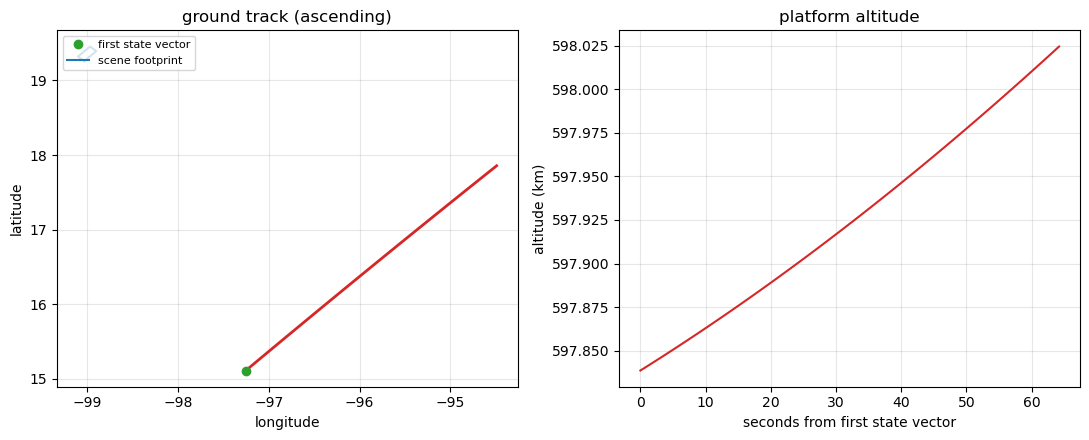

In [11]:
import pyproj

positions = np.array([sv.position.as_array() for sv in slc0.collect.state.state_vectors])
ecef_to_lla = pyproj.Transformer.from_crs(4978, 4326, always_xy=True)
sat_lon, sat_lat, sat_alt = ecef_to_lla.transform(*positions.T)

gcps = slc0.gcps
corner_gcps = [
    min(gcps, key=lambda g: (g.row, g.col)),
    min(gcps, key=lambda g: (g.row, -g.col)),
    min(gcps, key=lambda g: (-g.row, -g.col)),
    min(gcps, key=lambda g: (-g.row, g.col)),
]
footprint = np.array([[g.x, g.y] for g in corner_gcps + corner_gcps[:1]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(sat_lon, sat_lat, "-", lw=2, color="tab:red")
axes[0].plot(sat_lon[0], sat_lat[0], "o", color="tab:green", label="first state vector")
axes[0].plot(footprint[:, 0], footprint[:, 1], "-", color="tab:blue", label="scene footprint")
axes[0].set(xlabel="longitude", ylabel="latitude",
            title=f"ground track ({slc0.collect.state.direction})")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(np.arange(len(sat_alt)) * orbit.spacing, np.array(sat_alt) / 1e3,
             color="tab:red")
axes[1].set(xlabel="seconds from first state vector", ylabel="altitude (km)",
            title="platform altitude")
axes[1].grid(alpha=0.3)
fig.tight_layout()

## Checking the adapter with `geo2rdr`

Before running anything expensive, confirm the grid and orbit agree with the vendor's own geolocation. 
`isce3.geometry.geo2rdr` takes a lon/lat/height and returns the azimuth time and slant range at which the radar saw it. 

In [12]:
import isce3

ellipsoid = isce3.core.make_projection(4326).ellipsoid
zero_doppler = isce3.core.LUT2d()

# Pick a tie point near the middle of the scene.
gcp = sorted(gcps, key=lambda g: (g.row - slc0.shape[0] / 2) ** 2
             + (g.col - slc0.shape[1] / 2) ** 2)[0]

az_time, slant_range = isce3.geometry.geo2rdr(
    [np.deg2rad(gcp.x), np.deg2rad(gcp.y), gcp.z],
    ellipsoid=ellipsoid,
    orbit=orbit,
    doppler=zero_doppler,
    wavelength=radar_grid.wavelength,
    side=radar_grid.lookside,
)

row = (az_time - radar_grid.sensing_start) * radar_grid.prf
col = (slant_range - radar_grid.starting_range) / radar_grid.range_pixel_spacing

print(f"tie point at lon/lat/h = ({gcp.x:.6f}, {gcp.y:.6f}, {gcp.z:.1f})")
print(f"  Capella says   row {gcp.row:9.2f}   col {gcp.col:9.2f}")
print(f"  geo2rdr says   row {row:9.2f}   col {col:9.2f}")
print(f"  difference     row {row - gcp.row:9.2f}   col {col - gcp.col:9.2f}  pixels")

tie point at lon/lat/h = (-99.003819, 19.356036, 2245.2)
  Capella says   row   9595.50   col   5315.50
  geo2rdr says   row   9595.50   col   5315.50
  difference     row     -0.00   col     -0.00  pixels


## Coregistration in radar coordinates

The standard three steps, all from `isce3`:

1. **`rdr2geo`** on the reference: for each reference pixel, where on the ground is it? Needs a DEM. Output is lon/lat/height rasters on the reference grid.
2. **`geo2rdr`** on each secondary: for each of those ground points, where does it land in the secondary's grid? Output is a range and azimuth offset per reference pixel.
3. **`ResampSlc`**: sample the secondary at those offsets, producing an image on the reference grid.

Step 1 depends only on the reference and the DEM, so it runs once for the stack.

In [13]:
import sardem.dem

DEM_FILE = HERE / "dem.tif"

if not DEM_FILE.exists():
    w, s, e, n = CapellaSLC.from_file(slc_files[0]).bounds
    pad = 0.2  # room for the scene to shift between passes
    sardem.dem.main(
        output_name=str(DEM_FILE),
        bbox=(w - pad, s - pad, e + pad, n + pad),
        data_source="COP",
        output_type="float32",
        output_format="GTiff",
    )

dem = gdal.Open(str(DEM_FILE)).ReadAsArray()
print(f"Copernicus DEM {dem.shape},  {np.nanmin(dem):.0f} - {np.nanmax(dem):.0f} m")

[08/07 09:55:55] [INFO dem.py] Bounds: -99.30480956540806 19.05786541253151 -98.70287024531396 19.65387356444987


[08/07 09:55:55] [INFO cop_dem.py] Creating /Users/staniewi/repos/2026-isceplus/S08_Adding_new_sensors_with_isce3/dem.tif


[08/07 09:55:55] [INFO cop_dem.py] Fetching remote tiles...


[08/07 09:55:55] [INFO cop_dem.py] Running GDAL command:


[08/07 09:55:55] [INFO cop_dem.py] gdalwarp /vsicurl/https://raw.githubusercontent.com/scottstanie/sardem/master/sardem/data/cop_global.vrt /Users/staniewi/repos/2026-isceplus/S08_Adding_new_sensors_with_isce3/dem.tif -of GTiff -ot Float32 -te -99.3048611111111086 19.0576388888888886 -98.7026388888888846 19.6540277777777774 -tr 0.000277777777777777778 0.000277777777777777778 -s_srs "epsg:4326+3855" -t_srs "epsg:4326" -wo NUM_THREADS=4 -r nearest -wm 5000 -srcnodata 0 -dstnodata 0 -multi


Creating output file that is 2168P x 2147L.
0

...10...20...30...40...50...60...70...80...90...

Copernicus DEM (2147, 2168),  2210 - 4130 m


100 - done in 00:00:09.
journal:
 -- DEM EPSG: 4326
 -- Output EPSG: 4326
journal:
 -- Processing block: 1 
 --   - line start: 0
 --   - line end  : 1024
 --   - dopplers near mid far: 0 0 0 
journal: West limit may be insufficient for global height range
journal:
 -- Actual DEM bounds used:
 -- Top Left: -99.3047 19.5239
 -- Bottom Right: -98.8561 19.0881 
 -- Spacing: 0.000277778 -0.000277778
 -- Dimensions: 1616 1570

Topo progress (block 1/19): Done


journal:
 -- Processing block: 2 
 --   - line start: 1024
 --   - line end  : 2048
 --   - dopplers near mid far: 0 0 0 
journal:
 -- Actual DEM bounds used:
 -- Top Left: -99.3006 19.5311
 -- Bottom Right: -98.8489 19.095 
 -- Spacing: 0.000277778 -0.000277778
 -- Dimensions: 1627 1571

Topo progress (block 2/19): Done
journal:
 -- Processing block: 3 
 --   - line start: 2048
 --   - line end  : 3072
 --   - dopplers near mid far: 0 0 0 
journal:
 -- Actual DEM bounds used:
 -- Top Left: -99.2936 19.5381
 -- Bottom Right: -98.8417 19.1022 
 -- Spacing: 0.000277778 -0.000277778
 -- Dimensions: 1628 1570

Topo progress (block 3/19): Done
journal:
 -- Processing block: 4 
 --   - line start: 3072
 --   - line end  : 4096
 --   - dopplers near mid far: 0 0 0 
journal:
 -- Actual DEM bounds used:
 -- Top Left: -99.2864 19.5453
 -- Bottom Right: -98.8347 19.1094 
 -- Spacing: 0.000277778 -0.000277778
 -- Dimensions: 1627 1570

Topo progress (block 4/19): Done
journal:
 -- Processing block

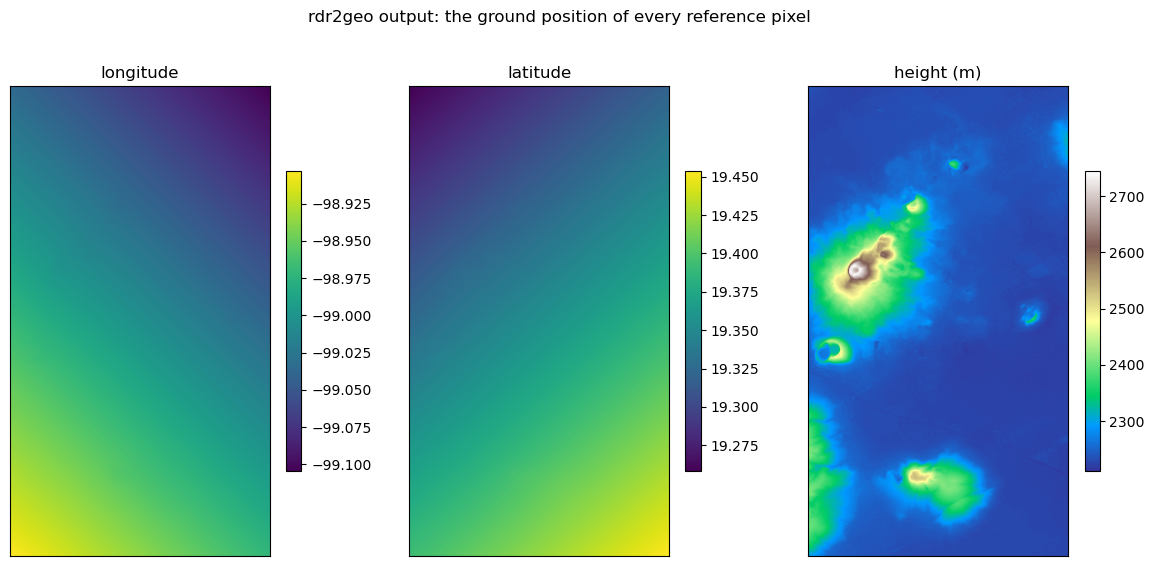

In [14]:
from capella_isce3_utils import run_geo2rdr, run_rdr2geo

REF_FILE = slc_files[0]
WORK_DIR = HERE / "coreg"
WORK_DIR.mkdir(exist_ok=True)

geometry_vrt = run_rdr2geo(REF_FILE, DEM_FILE, WORK_DIR)

# Read a decimated version for display; the full layers are 200 Mpx each.
geom_ds = gdal.Open(str(geometry_vrt))
DECIM = 16
lon, lat, hgt = geom_ds.ReadAsArray(
    buf_xsize=geom_ds.RasterXSize // DECIM, buf_ysize=geom_ds.RasterYSize // DECIM
)

fig, axes = plt.subplots(1, 3, figsize=(12, 5.5))
for ax, layer, name, cmap in zip(
    axes, [lon, lat, hgt], ["longitude", "latitude", "height (m)"], ["viridis", "viridis", "terrain"]
):
    im = ax.imshow(layer, cmap=cmap)
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set(title=name, xticks=[], yticks=[])
fig.suptitle("rdr2geo output: the ground position of every reference pixel", y=1.02)
fig.tight_layout()

These are radar-coordinate rasters: rows are azimuth, columns are slant range.
The height layer is the DEM resampled into radar geometry, which is exactly what
`geo2rdr` needs next.

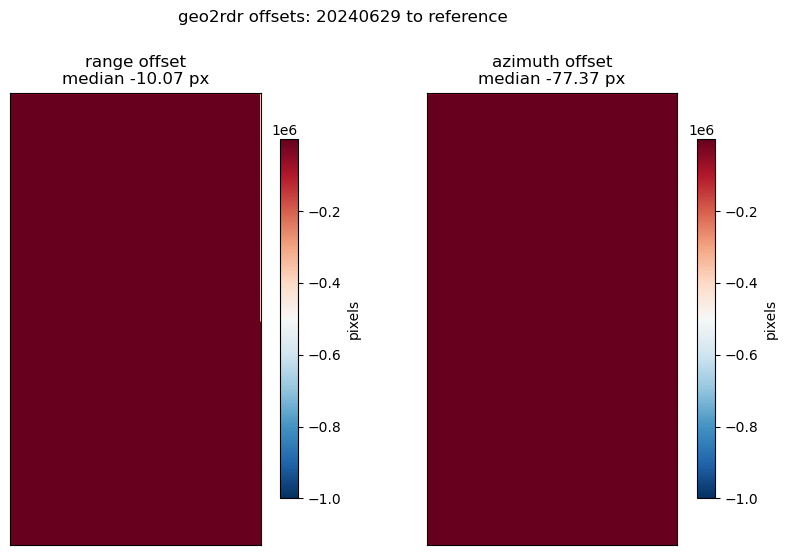

In [ ]:
SEC_FILE = slc_files[1]

rg_off_path, az_off_path = run_geo2rdr(SEC_FILE, geometry_vrt, WORK_DIR)

# geo2rdr writes flat float64 rasters on the reference grid.
full_shape = (geom_ds.RasterYSize, geom_ds.RasterXSize)
rg_off = np.memmap(rg_off_path, dtype=np.float64, mode="r", shape=full_shape)
az_off = np.memmap(az_off_path, dtype=np.float64, mode="r", shape=full_shape)

def mask_tiny(a):
    return np.ma.masked_where(a < -50_000, a)

fig, axes = plt.subplots(1, 2, figsize=(9, 5.5))
for ax, off, name in zip(axes, [rg_off, az_off], ["range offset", "azimuth offset"]):
    im = ax.imshow(mask_tiny(off[::DECIM, ::DECIM]), cmap="RdBu_r")
    fig.colorbar(im, ax=ax, fraction=0.046, label="pixels")
    ax.set(title=f"{name}\nmedian {np.median(off[::DECIM, ::DECIM]):+.2f} px",
           xticks=[], yticks=[])
fig.suptitle(f"geo2rdr offsets: {date_of(SEC_FILE)} to reference", y=1.0)
fig.tight_layout()

The offsets are a few pixels and vary smoothly across the scene &mdash; that is the
orbital baseline plus the topography, which is what we expect. A constant bias of
tens of pixels would mean a timing convention got mistranslated.

In [16]:
from capella_isce3_utils import form_interferogram, resample_slc

coarse_file = WORK_DIR / "coarse_resampled.tif"
coarse_file.unlink(missing_ok=True)
resample_slc(REF_FILE, SEC_FILE, rg_off_path, az_off_path, coarse_file)

LOOKS = (16, 16)  # ~17 x 15 m ground pixels
ifg_coarse, coh_coarse = form_interferogram(REF_FILE, coarse_file, looks=LOOKS)
print(f"geometry-only coregistration: mean coherence {np.nanmean(coh_coarse):.3f}")

geometry-only coregistration: mean coherence 0.080


### Refining with cross-correlation

The geometric offsets are only as good as the orbit and the DEM. We refine them
by cross-correlating amplitude chips between the reference and the coarsely
resampled secondary, then taking a robust median of the per-chip shifts. For
these scenes a constant shift is enough; a longer scene would want a polynomial
or a dense offset field.

144 chips, 139 inliers
residual bulk offset:  azimuth +1.844 px,  range -0.750 px


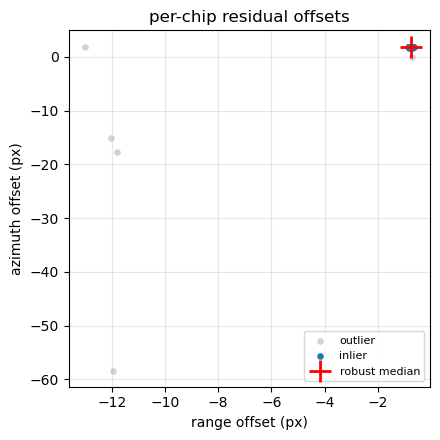

In [17]:
from capella_isce3_utils import bulk_offset, correlate_grid

# Chips are read through GDAL one window at a time, so this never holds more
# than a couple of 256x256 patches in memory.
az_chips, rg_chips, err = correlate_grid(
    REF_FILE, coarse_file, chip_size=(256, 256), n_chips=(12, 12)
)
az_med, rg_med, inliers = bulk_offset(az_chips, rg_chips)

print(f"{len(az_chips)} chips, {inliers.sum()} inliers")
print(f"residual bulk offset:  azimuth {az_med:+.3f} px,  range {rg_med:+.3f} px")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(rg_chips[~inliers], az_chips[~inliers], s=14, c="lightgray", label="outlier")
ax.scatter(rg_chips[inliers], az_chips[inliers], s=14, c="tab:blue", label="inlier")
ax.plot(rg_med, az_med, "r+", ms=16, mew=2, label="robust median")
ax.set(xlabel="range offset (px)", ylabel="azimuth offset (px)",
       title="per-chip residual offsets")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()

### The whole stack

`coregister_pair` chains geo2rdr, a coarse resample, the cross-correlation refinement, and a final resample from the original secondary using the summed offsets.

In [18]:
import time

from capella_isce3_utils import coregister_pair

COREG_DIR = HERE / "coregistered"
COREG_DIR.mkdir(exist_ok=True)

# The reference does not need resampling; it defines the grid.
ref_out = COREG_DIR / f"{date_of(REF_FILE)}.slc.tif"
if not ref_out.exists():
    gdal.Translate(str(ref_out), str(REF_FILE), format="GTiff", outputType=gdal.GDT_CFloat32)

t0 = time.time()
coreg_files = [ref_out]
for sec_file in slc_files[1:]:
    print(f"{date_of(sec_file)}:")
    coreg_files.append(
        coregister_pair(
            REF_FILE,
            sec_file,
            geometry_vrt,
            WORK_DIR,
            COREG_DIR / f"{date_of(sec_file)}.slc.tif",
        )
    )
print(f"\n{len(coreg_files)} SLCs on a common grid in {time.time() - t0:.0f} s")

20240629:


  bulk offset az=+1.844 rg=-0.750 px  (139/144 chips)


  20240629.slc.tif in 42.6 s
20240702:


  bulk offset az=+0.156 rg=+0.156 px  (139/144 chips)


  20240702.slc.tif in 42.2 s
20240705:
journal: Total convergence: 193506223 out of 204019521
journal:
 -- 
 -- Starting acquisition time: -1.64315
 -- Stop acquisition time: 1.43876
 -- Azimuth line spacing in seconds: 0.000161011
 -- Slant range spacing in meters: 0.617188
 -- Near range (m): 759635
 -- Far range (m): 766183
 -- Radar image length: 19142
 -- Radar image width: 10610
 -- Geocoded lines: 19191
 -- Geocoded samples: 10631
 -- Processing block: 0 
 --   - line start: 0
 --   - line end  : 1024
 --   - dopplers near mid far: 0 0 0 
journal:
 -- Processing block: 1 
 --   - line start: 1024
 --   - line end  : 2048
 --   - dopplers near mid far: 0 0 0 
journal:
 -- Processing block: 2 
 --   - line start: 2048
 --   - line end  : 3072
 --   - dopplers near mid far: 0 0 0 
journal:
 -- Processing block: 3 
 --   - line start: 3072
 --   - line end  : 4096
 --   - dopplers near mid far: 0 0 0 
journal:
 -- Processing block: 4 
 --   - line start: 4096
 --   - line end  : 512

...

  20240711.slc.tif in 40.3 s
20240714:


  bulk offset az=+0.156 rg=+0.000 px  (38/144 chips)


line start: 17408
 --   - line end  : 18432
 --   - dopplers near mid far: 0 0 0 
journal:
 -- Processing block: 18 
 --   - line start: 18432
 --   - line end  : 19191
 --   - dopplers near mid far: 0 0 0 
journal: Total convergence: 203109561 out of 204019521
Resampling using 19 tiles of 1024 lines per tile
Reading in image data for tile 0
Interpolating tile 0
Reading in image data for tile 1
Interpolating tile 1
Reading in image data for tile 2
Interpolating tile 2
Reading in image data for tile 3
Interpolating tile 3
Reading in image data for tile 4
Interpolating tile 4
Reading in image data for tile 5
Interpolating tile 5
Reading in image data for tile 6
Interpolating tile 6
Reading in image data for tile 7
Interpolating tile 7
Reading in image data for tile 8
Interpolating tile 8
Reading in image data for tile 9
Interpolating tile 9
Reading in image data for tile 10
Interpolating tile 10
Reading in image data for tile 11
Interpolating tile 11
Reading in image data for tile 12
Int

  bulk offset az=-0.250 rg=-0.312 px  (138/144 chips)


  20240717.slc.tif in 49.3 s

8 SLCs on a common grid in 304 s


after cross-correlation:      mean coherence 0.355


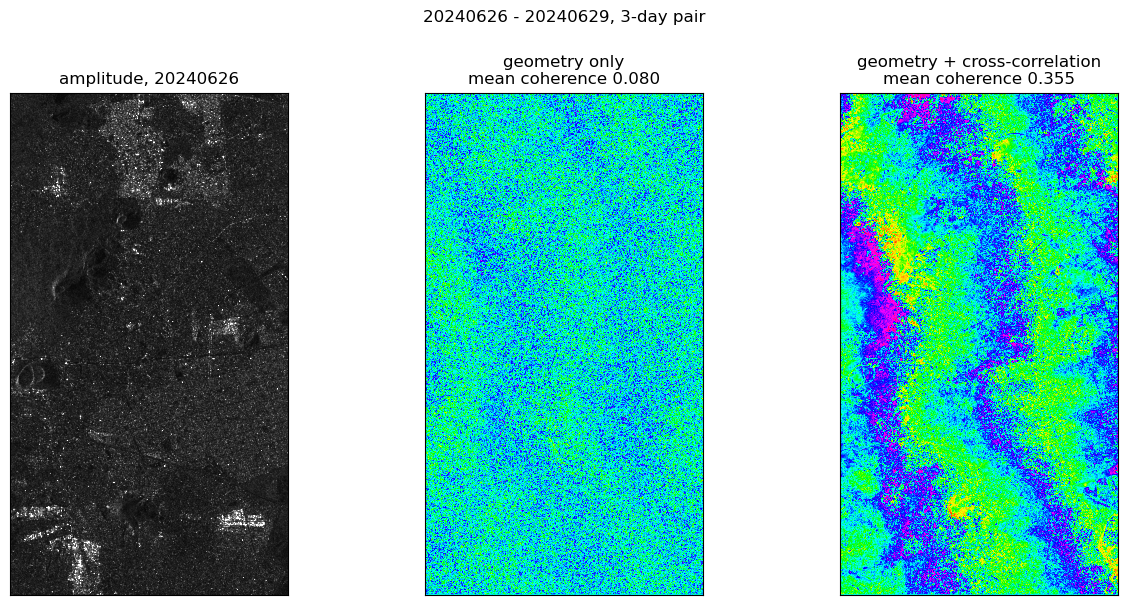

In [ ]:
ifg_fine, coh_fine = form_interferogram(coreg_files[0], coreg_files[1], looks=LOOKS)
print(f"after cross-correlation:      mean coherence {np.nanmean(coh_fine):.3f}")

ref_ds = gdal.Open(str(coreg_files[0]))
amp = np.abs(ref_ds.ReadAsArray(
    buf_xsize=ref_ds.RasterXSize // DECIM, buf_ysize=ref_ds.RasterYSize // DECIM
))

fig, axes = plt.subplots(1, 3, figsize=(13, 6))
axes[0].imshow(amp, cmap="gray", vmax=np.nanpercentile(amp, 99))
axes[0].set(title=f"amplitude, {date_of(REF_FILE)}", xticks=[], yticks=[])

for ax, ifg, coh, name in zip(
    axes[1:], [ifg_coarse, ifg_fine], [coh_coarse, coh_fine],
    ["geometry only", "geometry + cross-correlation"],
):
    ax.imshow(np.angle(ifg), cmap="hsv", vmin=-np.pi, vmax=np.pi, interpolation="none")
    ax.set(title=f"{name}\nmean coherence {np.nanmean(coh):.3f}", xticks=[], yticks=[])
fig.suptitle(f"{date_of(REF_FILE)} - {date_of(slc_files[1])}, 3-day pair", y=1.0)
fig.tight_layout()

Coherence goes from 0.08 to 0.36 after fine coregistration.

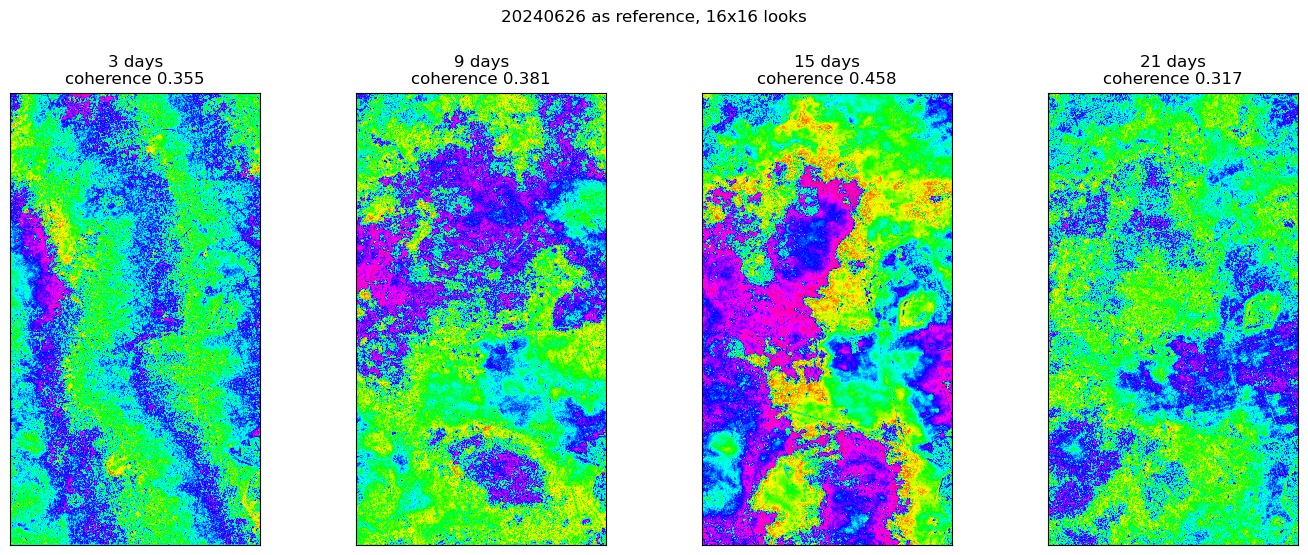

In [ ]:
def as_datetime64(path: Path) -> np.datetime64:
    """Acquisition date of a coregistered SLC."""
    d = date_of(path)
    return np.datetime64(f"{d[:4]}-{d[4:6]}-{d[6:]}")


ref_date = date_of(REF_FILE)
ref_day = as_datetime64(REF_FILE)
pair_idx = np.unique(np.linspace(1, len(coreg_files) - 1, 4).astype(int))

fig, axes = plt.subplots(1, len(pair_idx), figsize=(3.5 * len(pair_idx), 5.5))
for ax, i in zip(axes, pair_idx):
    ifg, coh = form_interferogram(coreg_files[0], coreg_files[i], looks=LOOKS)
    ax.imshow(np.angle(ifg), cmap="hsv", vmin=-np.pi, vmax=np.pi, interpolation="none")
    days = (as_datetime64(coreg_files[i]) - ref_day) / np.timedelta64(1, "D")
    ax.set(title=f"{days:.0f} days\ncoherence {np.nanmean(coh):.3f}",
           xticks=[], yticks=[])
fig.suptitle(f"{ref_date} as reference, {LOOKS[0]}x{LOOKS[1]} looks", y=1.0)
fig.tight_layout()

## 9. Running `dolphin` on the stack

`dolphin` was made to be agnostic to the input radar processor, as well as the coordinate convention.
For the most part, it does not try to guess conventions (an excaption being those used by COMPASS for Sentinel-1 bursts).
Therefore, to get output timeseries rasters in meters, we must specify the wavelength.

In [21]:
# Build the file list explicitly rather than globbing on the command line, so
# `N_SLCS` still controls the stack even when coregistered/ holds extra dates
# from an earlier run.
DOLPHIN_DIR = HERE / "mx_dolphin"
DOLPHIN_DIR.mkdir(exist_ok=True)
slc_arg = " ".join(str(p) for p in coreg_files)

print("\n".join(p.name for p in coreg_files))
print(f"\nwavelength to hand dolphin: {slc0.wavelength:.6f} m")

20240626.slc.tif
20240629.slc.tif
20240702.slc.tif
20240705.slc.tif
20240708.slc.tif
20240711.slc.tif
20240714.slc.tif
20240717.slc.tif

wavelength to hand dolphin: 0.031067 m


In [ ]:
!dolphin config \
    --slc-files {slc_arg} \
    --input-options.wavelength 0.031067 \
    --sy 5 --sx 5 \
    --phase-linking.half-window.y 11 --phase-linking.half-window.x 11 \
    --ps-options.amp-dispersion-threshold 0.05 \
    --unwrap-options.unwrap-method WHIRLWIND \
    --work-directory mx_dolphin \
    --outfile mx_dolphin/dolphin_config.yaml

Saving configuration to mx_dolphin/dolphin_config.yaml


* `--input-options.wavelength 0.031067`: X-band. Without it the `timeseries/` outputs stay in radians.
* `--sy 5 --sx 5`: output strides in pixels
* `--phase-linking.half-window 11 11`: the SHP search radius, also in pixels
* `--ps-options.amp-dispersion-threshold 0.05`: this is a short stack, so amplitude dispersion is biased low and the default 0.2 would label far too much of the city as persistent scatterer.

Expect two warnings on the way past: `Unable to parse OPERA bursts` and
`... is not a CSLC file`. Both are `dolphin` noticing that these are not OPERA
products and falling back to generic handling, which is what we want.

In [23]:
!dolphin run mx_dolphin/dolphin_config.yaml

[WARNING|displacement|L116] 2026-08-07T10:02:58-0400: Unable to parse OPERA bursts (Could not parse burst id from /Users/staniewi/repos/2026-isceplus/S08_Adding_new_sensors_with_isce3/coregistered/20240626.slc.tif), falling back to non-OPERA mode
[INFO|displacement|L240] 2026-08-07T10:02:58-0400: Found SLC files from 1 bursts/blocks
[INFO|wrapped_phase|L117] 2026-08-07T10:02:58-0400: Running wrapped phase estimation in /Users/staniewi/repos/2026-isceplus/S08_Adding_new_sensors_with_isce3/mx_dolphin/phase_linking
[WARNING|wrapped_phase|L612] 2026-08-07T10:02:58-0400: Could not make nodata mask: /Users/staniewi/repos/2026-isceplus/S08_Adding_new_sensors_with_isce3/coregistered/20240717.slc.tif is not a CSLC file
[INFO|wrapped_phase|L164] 2026-08-07T10:02:58-0400: Creating persistent scatterer file /Users/staniewi/repos/2026-isceplus/S08_Adding_new_sensors_with_isce3/mx_dolphin/phase_linking/PS/ps_pixels.tif


[INFO|_readers|L1169] 2026-08-07T10:02:58-0400: Processing (512, 512) sized blocks...

PS (/Users/staniewi/repos/2026-isceplus/S08_Adding_new_sensors_with_isce3/mx_dol


PS (/Users/staniewi/repos/2026-isceplus/S08_Adding_new_sensors_with_isce3/mx_dol


PS (/Users/staniewi/repos/2026-isceplus/S08_Adding_new_sensors_with_isce3/mx_dol


PS (/Users/staniewi/repos/2026-isceplus/S08_Adding_new_sensors_with_isce3/mx_dol

...


100%|███████████████████████████████████████████| 15/15 [00:00<00:00, 15.26it/s]


[INFO|timeseries|L1229] 2026-08-07T10:07:44-0400: Completed invert_unw_network
[INFO|timeseries|L233] 2026-08-07T10:07:44-0400: Creating overviews for timeseries images

  0%|                                                     | 0/7 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████| 7/7 [00:00<00:00, 89.95it/s]
[INFO|timeseries|L237] 2026-08-07T10:07:44-0400: Estimating phase velocity
[INFO|timeseries|L833] 2026-08-07T10:07:44-0400: Using unweighted fit for velocity.
[INFO|timeseries|L839] 2026-08-07T10:07:44-0400: Reading phase reference pixel ReferencePoint(row=425, col=91)

  0%|                                                    | 0/15 [00:00<?, ?it/s]


 87%|████████████████████████████████████▍     | 13/15 [00:00<00:00, 108.51it/s]


100%|██████████████████████████████████████████| 15/15 [00:00<00:00, 109.72it/s]
[INFO|timeseries|L891] 2026-08-07T10:07:44-0400: Creating overviews for velocity image

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 41.85it/s]
[INFO|timeseries|L906] 2026-08-07T10:07:44-0400: Completed create_velocity
[INFO|displacement|L517] 2026-08-07T10:07:44-0400: Maximum memory usage: 3.05 GB
[INFO|displacement|L518] 2026-08-07T10:07:44-0400: Config file dolphin version: 0.42.3.post1.dev77+g0e4df9899.d20260419
[INFO|displacement|L519] 2026-08-07T10:07:44-0400: Current running dolphin version: 0.42.3.post1.dev77+g0e4df9899.d20260419
[INFO|_log|L102] 2026-08-07T10:07:44-0400: Total elapsed time for dolphin.workflows.displacement.run : 4.76 minutes (285.77 seconds)


## 10. Results

8 acquisitions over 21 days
LOS velocity, cm/yr
   p1 -21.6   median 0.0   p99 33.1


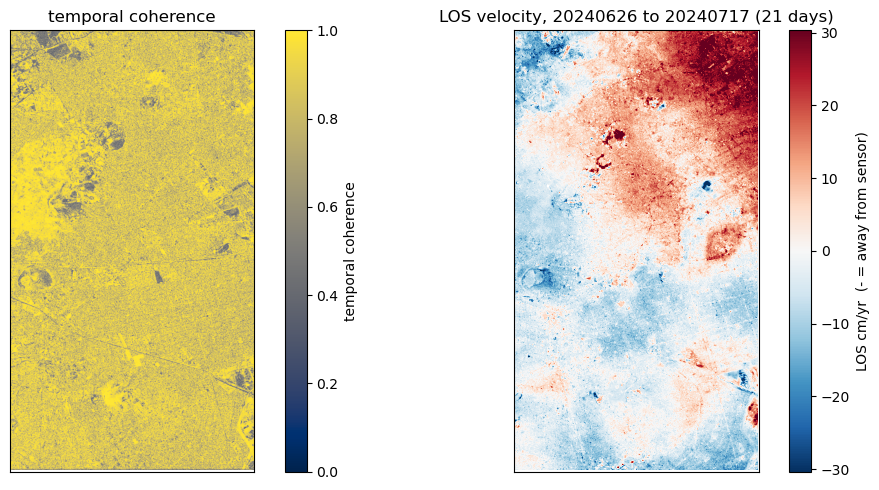

In [24]:
import xarray as xr

DOLPHIN = HERE / "mx_dolphin"

# `!` cells do not raise when the command fails, so check the outputs landed
# rather than failing later with something cryptic.
tcoh_paths = sorted((DOLPHIN / "interferograms").glob("temporal_coherence_*.tif"))
assert tcoh_paths, f"no dolphin output in {DOLPHIN}; re-read the two cells above"

tcoh_path = tcoh_paths[0]
tcoh = xr.open_dataarray(tcoh_path).squeeze().values
tcoh = np.where(np.isfinite(tcoh), tcoh, np.nan)

vel = xr.open_dataarray(DOLPHIN / "timeseries" / "velocity.tif").squeeze().values
vel_cm = np.where(np.isfinite(vel) & (vel != 0), vel * 100.0, np.nan)
# Dolphin picks an arbitrary high-coherence reference pixel; re-reference to the
# median of the scene so the map reads as relative subsidence.
vel_cm = vel_cm - np.nanmedian(vel_cm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im = axes[0].imshow(tcoh, cmap="cividis", vmin=0, vmax=1)
fig.colorbar(im, ax=axes[0], fraction=0.046, label="temporal coherence")
axes[0].set(title="temporal coherence", xticks=[], yticks=[])

vmax = np.nanpercentile(np.abs(vel_cm), 98)
im = axes[1].imshow(vel_cm, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
fig.colorbar(im, ax=axes[1], fraction=0.046, label="LOS cm/yr  (- = away from sensor)")
span_days = (as_datetime64(coreg_files[-1]) - ref_day) / np.timedelta64(1, "D")
axes[1].set(title=f"LOS velocity, {ref_date} to {date_of(coreg_files[-1])}"
                  f" ({span_days:.0f} days)", xticks=[], yticks=[])
fig.tight_layout()

print(f"{len(coreg_files)} acquisitions over {span_days:.0f} days")
print("LOS velocity, cm/yr")
print("   p1 {:.1f}   median {:.1f}   p99 {:.1f}".format(
    *np.nanpercentile(vel_cm, [1, 50, 99])))


## Further reading

* [Capella Space SAR Products Format Specification v1.8](https://support.capellaspace.com/hubfs/Capella_Space_SAR_Products_Format_Specification_v1.8.pdf?hsLang=en) * [`capella-reader`](https://github.com/capellaspace/capella-reader)including `docs/examples/`, which has the spotlight-mode phase restoration this notebook skipped
* [`s1-reader`](https://github.com/isce-framework/s1-reader) and [COMPASS](https://github.com/opera-adt/COMPASS)
* [ISCE3](https://github.com/isce-framework/isce3) and its [API documentation](https://isce-framework.github.io/isce3/)
* [Capella Open Data catalog](https://www.capellaspace.com/earth-observation-solutions/capella-open-data/)